# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [47]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Also set sns theme to 'whitegrid' and default figure size to (10,5)



## Task 2 — Load & Inspect Data

In [48]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df =pd.read_csv(url, sep='\s+', names=col_names, na_values='?')

print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [49]:
# TODO: Print df.info() to inspect dtypes and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None


In [50]:
print(df.isnull().sum())    

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [51]:
# TODO: Print df.describe() to view summary statistics
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year      origin  
count    398.000000  398.000000  398.000000  
mean      15.568090   76.010050    1.572864  
std        2.757689    3.697627    0.802055  
min        8.000000   70.000000    1.000000  
25%       13.825000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%       17.175000   79.0000

**Q1.** How many rows and columns does the dataset have?  
**Answer:** (398, 9)

**Q2.** Which column contains missing values and how many?  
**Answer:** HOURSE POWER HAVE 6 NULL VALUES


## Task 3 — Pre-Processing

In [52]:
# TODO: Check and print missing values per column
print('Missing values per column:\n', df.isnull().sum())

# Then drop all rows that contain NaN values (they are < 2% of data)
df.dropna(inplace=True)     
print("Shape after dropping NaNs:", df.shape)


Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64
Shape after dropping NaNs: (392, 9)


In [53]:
# TODO: Check for and remove duplicate rows
print("Duplicate Rows:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate Rows: 0
Shape after dropping duplicates: (392, 9)


In [54]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
df['cylinders'] =df['cylinders'].astype('category')
df['model_year'] =df['model_year'].astype('category')       

# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
origin_mapping = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_mapping)
# 3. Strip & lowercase 'car_name'

df['car_name'] = df['car_name'].str.strip().str.lower()


In [55]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)

# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']   # fill in
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']   # fill in


## Task 4 — Feature Engineering

In [56]:
# TODO: Create 'mpg_level' column using pd.cut()
df['mpg_level'] = pd.cut(df['mpg'], bins=[0,17,29,np.inf], labels=['low','medium','high'], right=False)

# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'



In [57]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]       


## Task 5 — Categorical EDA

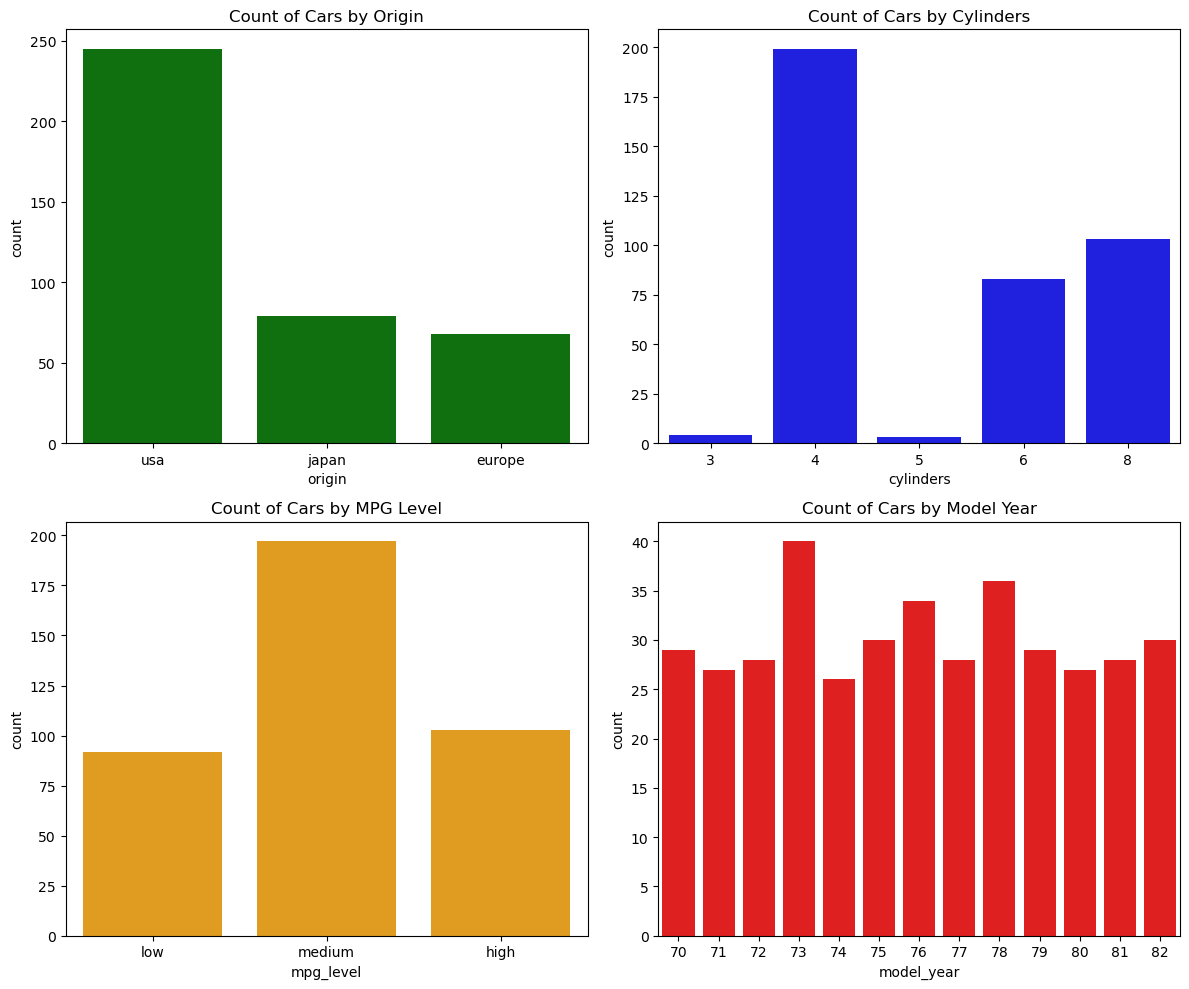

In [58]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year

# Arrange them in a 2×2 grid of subplots
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.countplot(data=df, x='origin',color='green')
plt.title('Count of Cars by Origin')
plt.subplot(2,2,2)
sns.countplot(data=df, x='cylinders',color='blue')
plt.title('Count of Cars by Cylinders')
plt.subplot(2,2,3)
sns.countplot(data=df, x='mpg_level',color='orange')
plt.title('Count of Cars by MPG Level')
plt.subplot(2,2,4)
sns.countplot(data=df, x='model_year',color='red')
plt.title('Count of Cars by Model Year')
plt.tight_layout()
plt.show()

In [59]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin', 'cylinders', 'mpg_level']:
    prop = df[col].value_counts(normalize=True).max() * 100
    print(f"Dominant class proportion in '{col}': {prop:.2f}%") 
    


Dominant class proportion in 'origin': 62.50%
Dominant class proportion in 'cylinders': 50.77%
Dominant class proportion in 'mpg_level': 50.26%


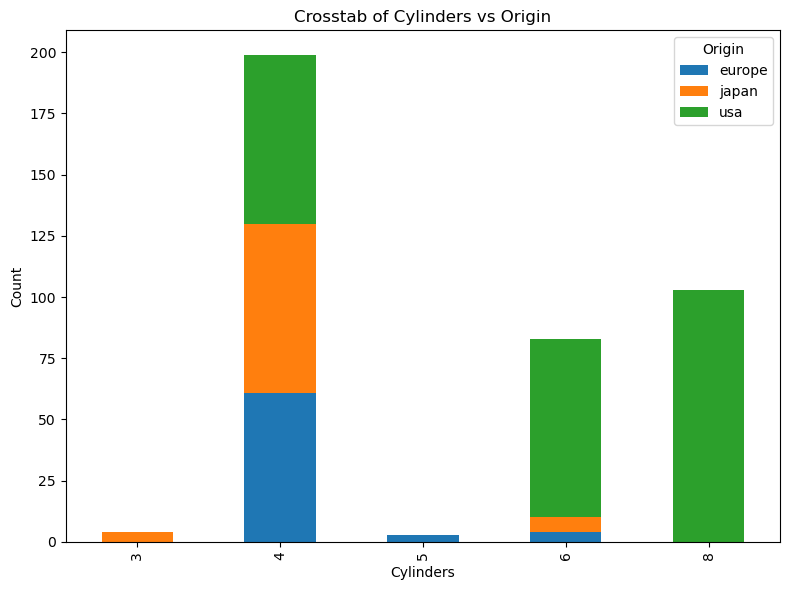

In [60]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
crosstab = pd.crosstab(df['cylinders'], df['origin'])
crosstab.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title('Crosstab of Cylinders vs Origin')
plt.xlabel('Cylinders')
plt.ylabel('Count')
plt.legend(title='Origin')
plt.tight_layout()  


Text(0, 0.5, 'Count')

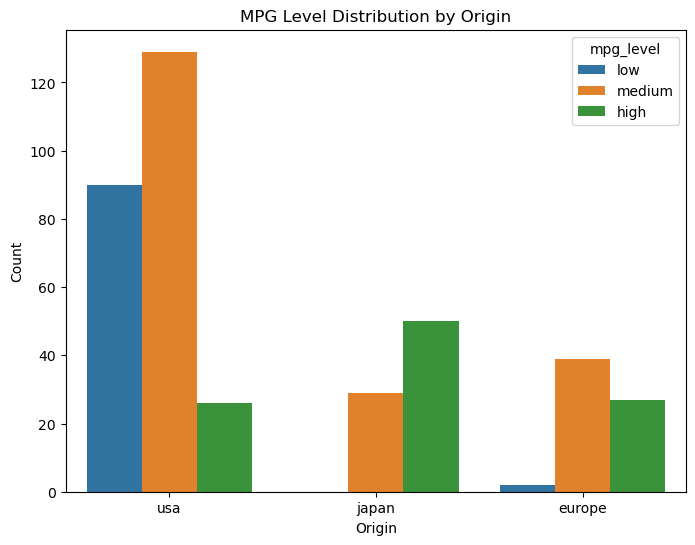

In [61]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')

plt.figure(figsize=(8,6))
sns.countplot(data=df, x='origin', hue='mpg_level')
plt.title('MPG Level Distribution by Origin')
plt.xlabel('Origin')
plt.ylabel('Count') 

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** Japan

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 


## Task 6 — Numerical EDA

In [62]:
# TODO: For each numerical column plot:

#   (a) Histogram + KDE  (b) Boxplot

# Arrange in a grid (n_cols rows × 2 columns)
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols     


In [63]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values

# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR

# Then print the outlier count for each numerical column

def tukey_outliers(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = series[(series < lower_bound) | (series > upper_bound)]
        return outliers                 
for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"Outliers in '{col}': {len(outliers)}")     




Outliers in 'mpg': 0
Outliers in 'displacement': 0
Outliers in 'horsepower': 10
Outliers in 'weight': 0
Outliers in 'acceleration': 11


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

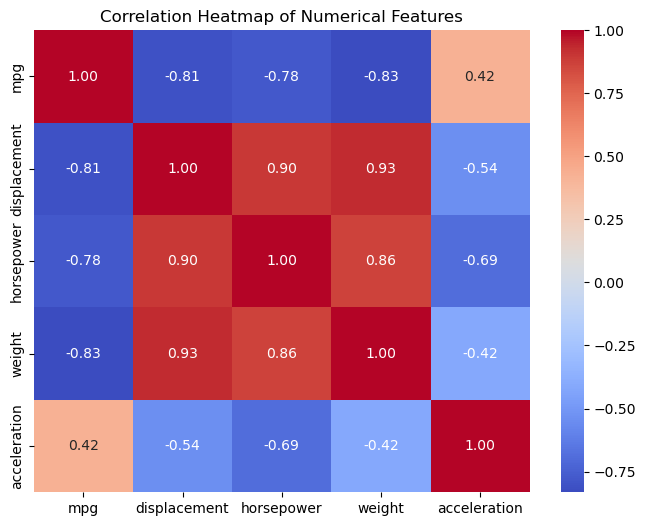

In [64]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')              



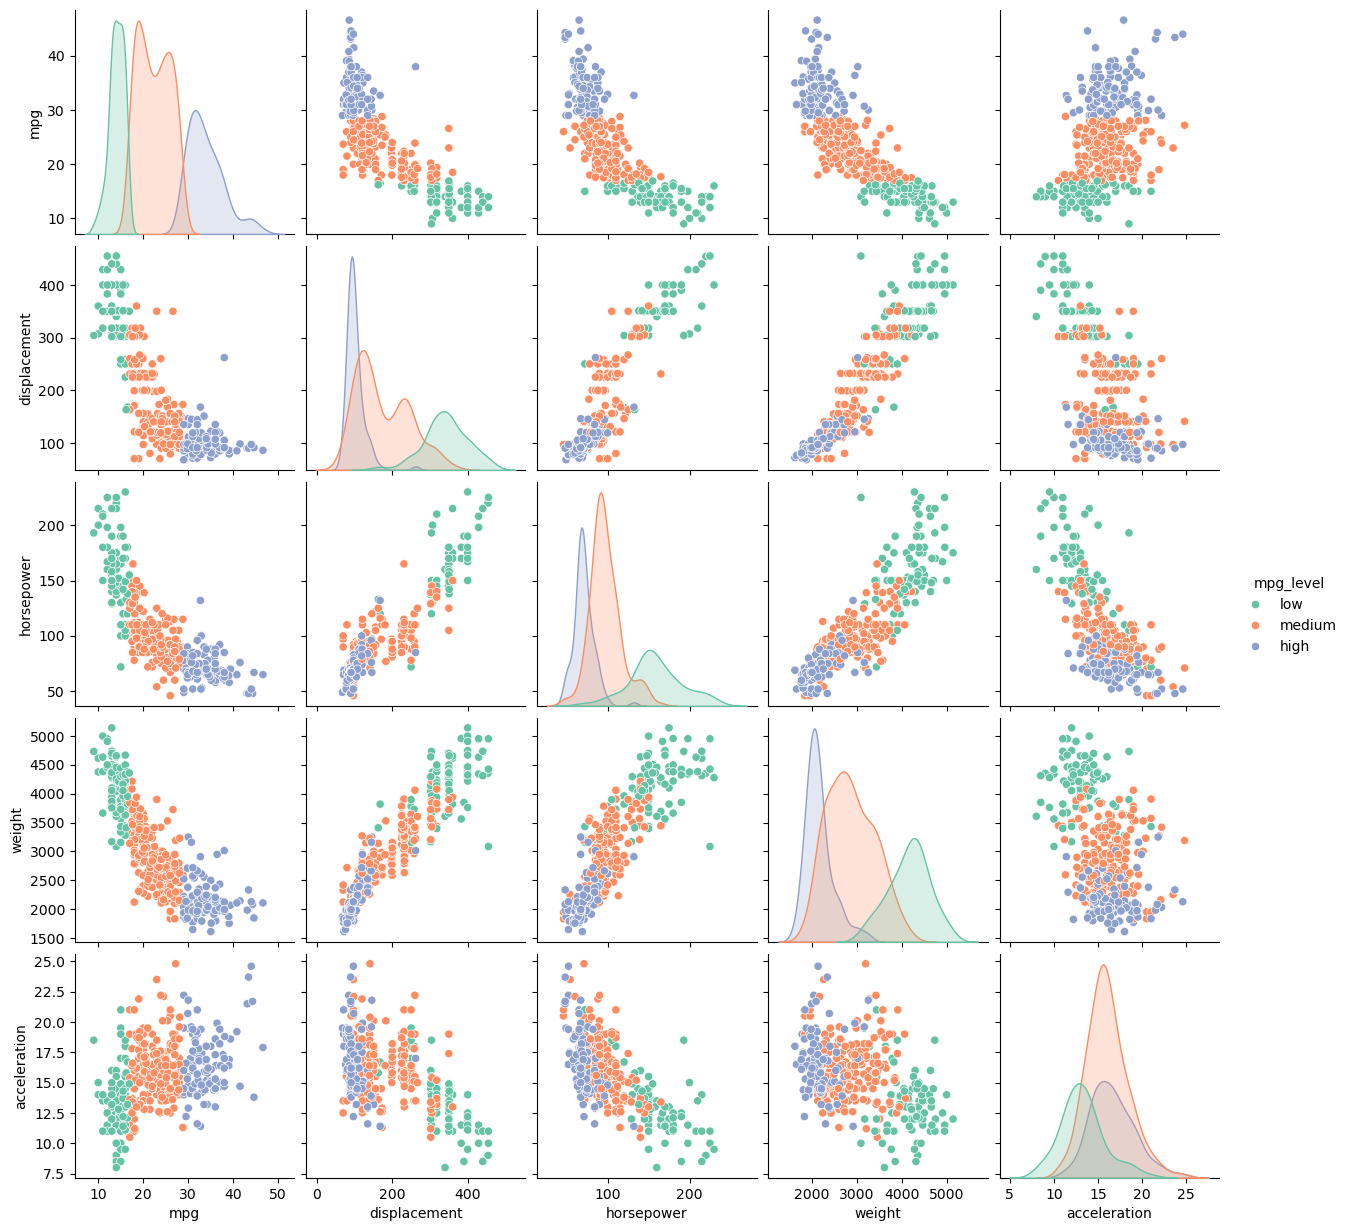

In [65]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level', diag_kind='kde', palette='Set2')        



**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** weight and displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** Yes, it is approximately Gaussian because the distribution appears roughly bell-shaped and symmetric in the KDE plot.


## Task 7 — Numerical vs Categorical

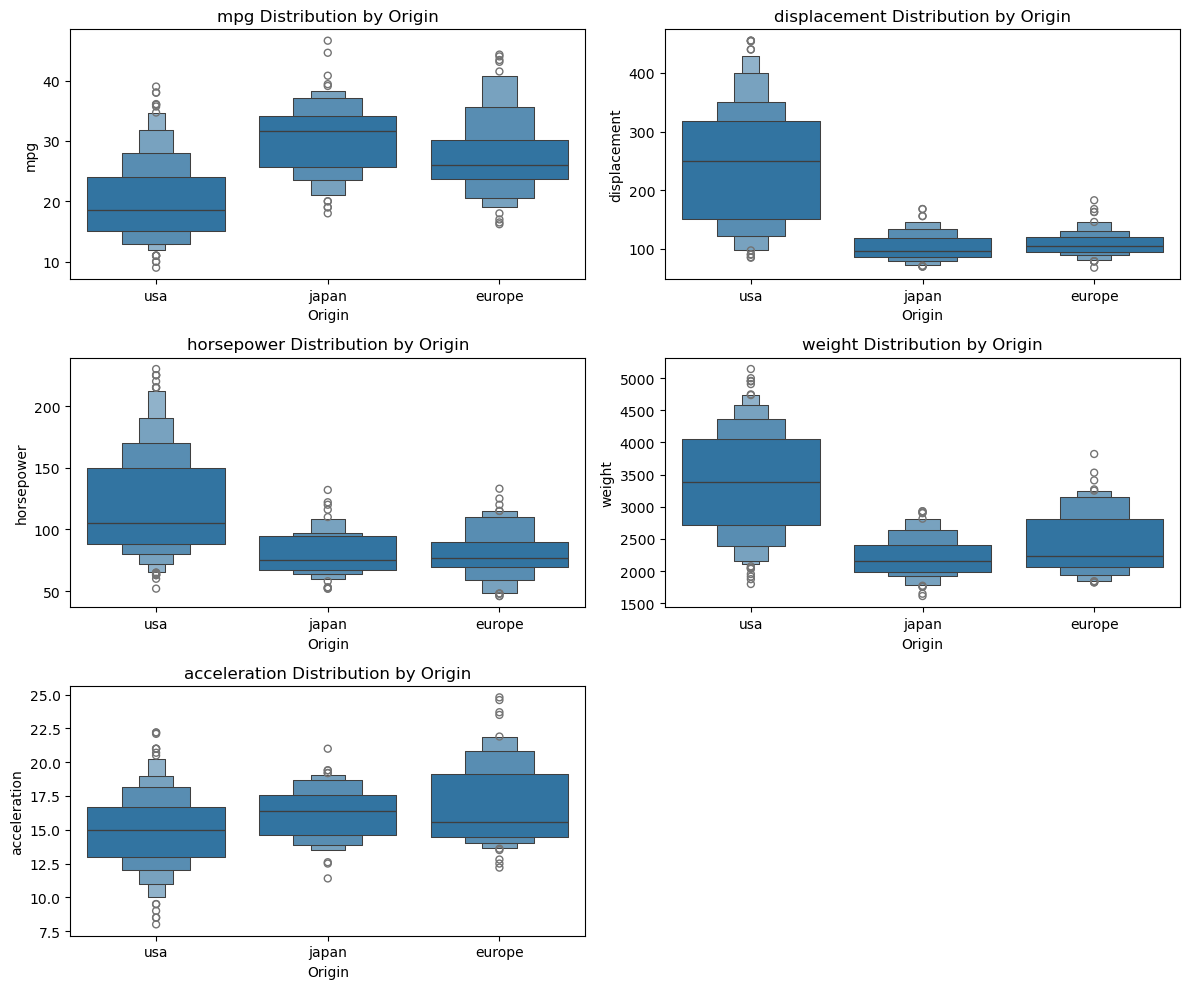

In [66]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
plt.figure(figsize=(12,10))
for i, col in enumerate(num_cols):          
# (1 row × 5 column subplot grid)
    plt.subplot(3,2,i+1)
    sns.boxenplot(data=df, x='origin', y=col)
    plt.title(f'{col} Distribution by Origin')
    plt.xlabel('Origin')
    plt.ylabel(col)
plt.tight_layout()  



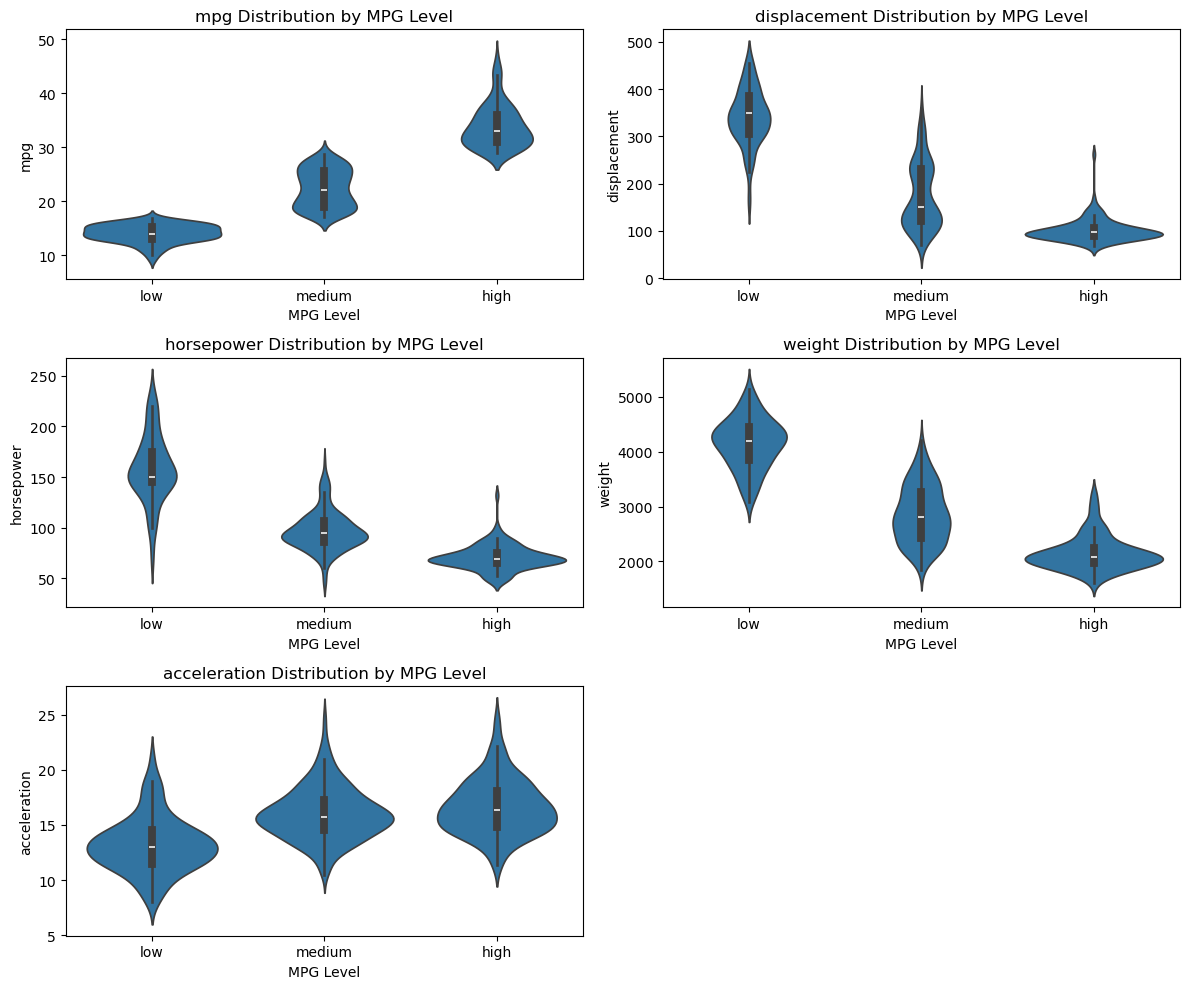

In [67]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'

plt.figure(figsize=(12,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.violinplot(data=df, x='mpg_level', y=col)
    plt.title(f'{col} Distribution by MPG Level')
    plt.xlabel('MPG Level')
    plt.ylabel(col)
plt.tight_layout()  

C:\Users\hp\AppData\Local\Temp\ipykernel_3296\207446320.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mpg_year = df.groupby('model_year')['mpg'].mean().reset_index()


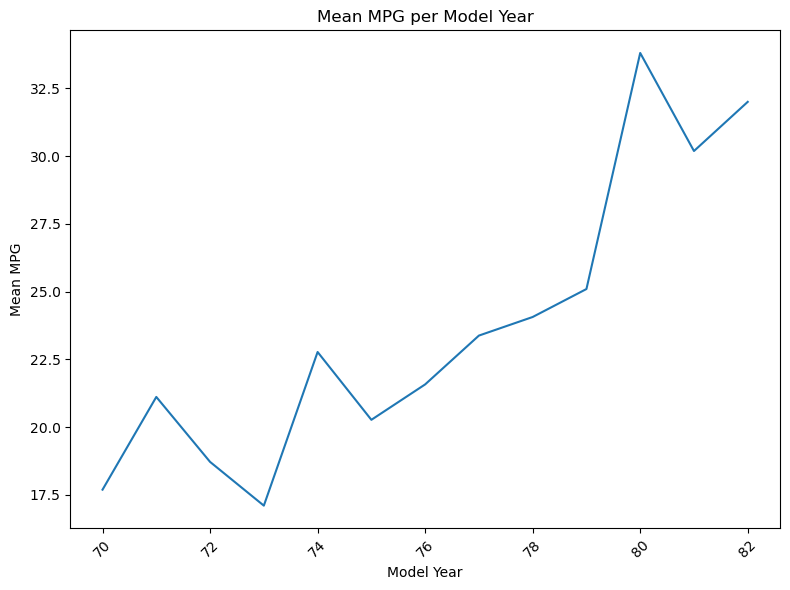

In [68]:
# TODO: Plot a line chart showing mean mpg per model_year
mean_mpg_year = df.groupby('model_year')['mpg'].mean().reset_index()
plt.figure(figsize=(8,6))
sns.lineplot(data=mean_mpg_year, x='model_year', y='mpg')
plt.title('Mean MPG per Model Year')            
plt.xlabel('Model Year')
plt.ylabel('Mean MPG')
plt.xticks(rotation=45)
plt.tight_layout()


**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** _______________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** 80


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
